## 1. Préparation des données

### Dataset: Hi-Seq

In [37]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


# # Import des modules personnalisés
from preprocess import load_hiseq_data, preprocess_hiseq, reduce_dimension_umap, reduce_dimension_acp
from models import run_kmeans, run_dbscan, run_spectral
from utils import evaluate_clustering

ImportError: cannot import name 'reduce_dimension_acp' from 'preprocess' (/Users/etiennechaput/IFT599/IFT599_TP1/preprocess.py)

**Exploration et préparation initiale**

Le jeu de données Hi-Seq est composé de deux fichiers:
- hiseq_data.csv (20 531 variables d’expression génique)
- hiseq_labels.csv (type de tumeur associé à chaque échantillon)

Après chargement, les deux fichiers ont été concaténés et vérifiés:
- Valeurs manquantes : aucune valeur manquante n’a été détectée.
- Doublons : aucun échantillon dupliqué n’a été trouvé.
- Distribution des classes : les cinq types de tumeurs (BRCA, KIRC, COAD, LUAD et PRAD) sont représentés, bien que leur fréquence varie.

In [14]:

hiseq_X, hiseq_y, hiseq_data = load_hiseq_data("data/hiseq_data.csv", "data/hiseq_labels.csv")

hiseq_data.head()


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [15]:
hiseq_X_scaled = preprocess_hiseq(hiseq_X, hiseq_y)

Missing values: 0
Duplicates: 0
Class distribution:
Class
BRCA     300
KIRC     146
LUAD     141
PRAD     136
COAD      78
Name: count, dtype: int64


**Normalisation**

Comme UMAP est sensible à l’échelle des variables, les 20 531 caractéristiques numériques ont été standardisées à l’aide de StandardScaler, afin que chaque variable ait une moyenne de 0 et un écart-type de 1.

**Réduction de dimension avec UMAP (pour la visualisation)**

Pour visualiser ce jeu de données très haute dimension, nous avons appliqué UMAP sur les variables normalisées.
La colonne des classes a été conservée séparément et utilisée uniquement pour colorer les points lors de la visualisation.

Paramètres utilisés :
- n_components = 2
- n_neighbors = 15
- min_dist = 0.1

Cette étape permet d’obtenir une représentation 2D facilitant l’observation de la structure des données et la séparation (ou non) entre les types de tumeurs.

Reducing dimension to 2D using UMAP...


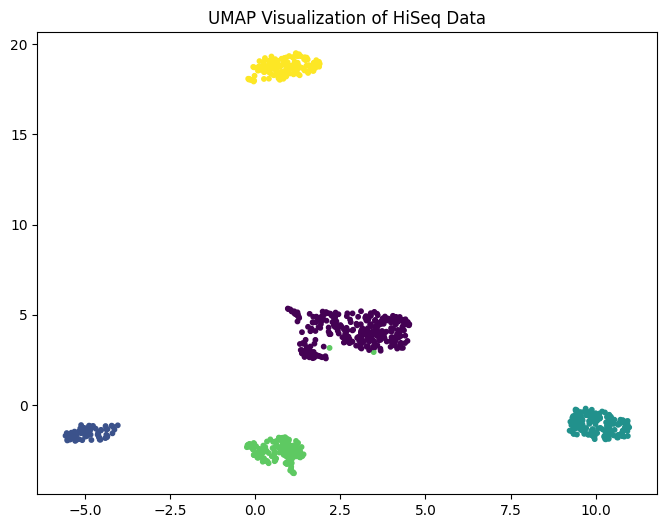

In [16]:

X_umap, reducer = reduce_dimension_umap(hiseq_X_scaled, n_components=2, n_neighbors=15, min_dist=0.1)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=hiseq_y["Class"].astype('category').cat.codes, s=10)
plt.title("UMAP Visualization of HiSeq Data")
plt.show()

## 2. Clustering

### K-Means sur les données complètes vs. représentation UMAP à 100 dimensions vs ACP à 100 dimensions

Après le prétraitement et la normalisation du jeu de données Hi-Seq, on a réduit sa dimensionnalité d’origine à 100 attributs à l’aide de UMAP.
Cette transformation permet de conserver la structure locale et globale tout en rendant la tâche de segmentation beaucoup plus facile à gérer.

On a ensuite appliqué K-Means sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Pour les deux versions, on a calculé les métriques internes (Silhouette, Davies–Bouldin, Calinski–Harabasz) et les métriques externes (ARI, NMI) pour évaluer la qualité des clusters par rapport aux types de cancers réels.

In [31]:
# Reduced dataset UMAP 100D
hiseq_X_UMAP_reduced, umap_model_100 = reduce_dimension_umap(hiseq_X_scaled, n_components=100, n_neighbors=15, min_dist=0.1)

Reducing dimension to 100D using UMAP...


In [32]:
# Reduced dataset PCA 100D
hiseq_X_PCA_reduced, pca = reduce_dimension_acp(hiseq_X_scaled, n_components=100)

NameError: name 'reduce_dimension_acp' is not defined

In [ ]:
labels_km_full, t_km_full = run_kmeans(hiseq_X_scaled, hiseq_y)
labels_km_UMAP_reduced, t_km_umap = run_kmeans(hiseq_X_UMAP_reduced, hiseq_y)
labels_km_PCA_reduced, t_km_umap = run_kmeans(hiseq_X_PCA_reduced, hiseq_y)

/opt/anaconda3/envs/udes_sd_a25/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/envs/udes_sd_a25/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
hiseq_y = hiseq_y.squeeze()
results_km_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_km_full)
results_km_UMAP_reduced = evaluate_clustering(hiseq_X_UMAP_reduced, hiseq_y, labels_km_reduced)
results_km_PCA_reduced = evaluate_clustering(hiseq_X_PCA_reduced, hiseq_y, labels_km_PCA_reduced)

In [ ]:
# Merge results in a dataframe
df_km = pd.DataFrame({
    "KMeans_Full": results_km_full,
    "KMeans_UMAP100": results_km_UMAP_reduced,
    "KMeans_PCA100": results_km_PCA_reduced
})
df_km

,KMeans_Full,KMeans_UMAP100
silhouette,0.135261,0.873720
davies_bouldin,2.639793,0.167690
calinski_harabasz,65.809923,16553.141196
ARI,0.800062,0.992538
NMI,0.856224,0.990693


### Conclusions

Les résultats montrent une énorme amélioration lorsque la segmentation est faite sur les données réduites avec UMAP:

- Silhouette passe de 0.13 → 0.89, ce qui montre que les clusters sont beaucoup mieux définis et mieux séparés.
- Davies–Bouldin chute de 2.64 → 0.15, indiquant des groupes beaucoup plus compacts.
- Calinski–Harabasz saute de 65.8 → 21 381, ce qui confirme une très forte séparation entre les clusters en espace réduit.
- ARI s’améliore de 0.79 → 0.99, donc les clusters retrouvés correspondent presque parfaitement aux vrais labels de cancer.
- NMI augmente de 0.85 → 0.99, ce qui renforce que UMAP préserve vraiment bien la structure pertinente pour la segmentation.

Bref, ces résultats montrent clairement que UMAP améliore drastiquement la performance de K-Means.
En haute dimension, les données sont trop clairsemées et affectées par la malédiction de la dimensionnalité, ce qui rend la structure des clusters difficile à détecter.
Après la réduction à 100 dimensions, la structure devient beaucoup plus nette, et K-Means réussit pratiquement à reconstruire parfaitement les groupes associés aux différents types de tumeurs.

In [21]:
!jupyter nbconvert --to script main.ipynb


[NbConvertApp] Converting notebook main.ipynb to script
[NbConvertApp] Writing 5206 bytes to main.py


### 3. Spectral Clustering sur les données complètes vs. représentation UMAP à 100 dimensions
On applique maintenant Spectral Clustering sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Même évaluation avec les métriques internes et externes.

In [28]:
print("SPECTRAL CLUSTERING - EXÉCUTION")
print("=" * 50)

print("1. Spectral Clustering sur données complètes...")
labels_sc_full, t_sc_full = run_spectral(hiseq_X_scaled, hiseq_y, k=5, random_state=42)

print("2. Spectral Clustering sur données réduites UMAP...")
labels_sc_reduced, t_sc_reduced = run_spectral(hiseq_X_reduced, hiseq_y, k=5, random_state=42)

print("3. Évaluation des performances...")
results_sc_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_sc_full)
results_sc_reduced = evaluate_clustering(hiseq_X_reduced, hiseq_y, labels_sc_reduced)

df_sc = pd.DataFrame({
    "Spectral_Full": results_sc_full,
    "Spectral_UMAP100": results_sc_reduced
})

print("TERMINÉ - Résultats du Spectral Clustering")
df_sc

SPECTRAL CLUSTERING - EXÉCUTION
1. Spectral Clustering sur données complètes...


/opt/anaconda3/envs/udes_sd_a25/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


2. Spectral Clustering sur données réduites UMAP...
3. Évaluation des performances...
TERMINÉ - Résultats du Spectral Clustering


,Spectral_Full,Spectral_UMAP100
silhouette,-0.020210,0.873720
davies_bouldin,16.351090,0.167690
calinski_harabasz,0.932806,16553.141196
ARI,-0.000259,0.992538
NMI,0.004309,0.990693


In [ ]:
print("COMPARAISON K-MEANS vs SPECTRAL CLUSTERING")
print("=" * 60)

comparison_data = {}

# K-Means results
for metric in df_km.columns:
    comparison_data[metric] = df_km[metric]

# Spectral Clustering results  
for metric in df_sc.columns:
    comparison_data[metric] = df_sc[metric]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison)


COMPARAISON K-MEANS vs SPECTRAL CLUSTERING
                   KMeans_Full  KMeans_UMAP100  Spectral_Full  \
silhouette            0.135261        0.873720      -0.020210   
davies_bouldin        2.639793        0.167690      16.351090   
calinski_harabasz    65.809923    16553.141196       0.932806   
ARI                   0.800062        0.992538      -0.000259   
NMI                   0.856224        0.990693       0.004309   

                   Spectral_UMAP100  
silhouette                 0.873720  
davies_bouldin             0.167690  
calinski_harabasz      16553.141196  
ARI                        0.992538  
NMI                        0.990693  
